In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

import prince  # FAMD library

In [29]:
categorical_cols = [
    'gender', 'employment_type', 'residence', 'age_group', 
    'bmi_category', 'smoking_habit', 'lifestyle_risk'
]

numeric_cols = [
    'age', 'has_hypertension', 'has_heart_disease', 'marital_status',
    'glucose_level', 'bmi_value', 'risk_score', 'high_glucose'
]


df = pd.read_csv('../data/train.csv')

df_analysis = df.copy()

num_imputer = SimpleImputer(strategy='median')
df_analysis[numeric_cols] = num_imputer.fit_transform(df_analysis[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df_analysis[categorical_cols] = cat_imputer.fit_transform(df_analysis[categorical_cols])

In [30]:
for col in categorical_cols:
    df_analysis[col] = df_analysis[col].astype(str)

scaler = StandardScaler()
df_analysis[numeric_cols] = scaler.fit_transform(df_analysis[numeric_cols])

famd = prince.FAMD(
    n_components=10,   # you can tune this
    random_state=65
)

famd_fit = famd.fit(df_analysis[numeric_cols + categorical_cols])

X_famd = famd.transform(df_analysis[numeric_cols + categorical_cols])

In [31]:
eig_sum = famd.eigenvalues_summary
display(eig_sum)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,11.167,19.59%,19.59%
1,6.803,11.93%,31.53%
2,5.702,10.00%,41.53%
3,4.167,7.31%,48.84%
4,3.783,6.64%,55.48%
5,3.673,6.44%,61.92%
6,3.541,6.21%,68.13%
7,3.400,5.96%,74.10%
8,3.215,5.64%,79.74%


In [32]:
famd_df = famd.column_coordinates_

# Mask values with |value| < 0.5
masked_df = famd_df.where(np.abs(famd_df) >= 0.5, "")

styled_df = masked_df.style.background_gradient(cmap='RdYlGn')

display(styled_df)

component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
age,0.614510,,,,,,,,,
has_hypertension,,,,,,,,,,
has_heart_disease,,,,,,,,,,
marital_status,,,,,,,,,,
glucose_level,,,,,,,,,,
bmi_value,,,,,,,,,,
risk_score,,,,,,,,,,
high_glucose,,,,,,,,,,
age_group,0.638305,,,,,,,,,


In [33]:
K_range = range(2, 11)
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_famd)
    
    score = silhouette_score(X_famd, labels)
    silhouette_scores.append(score)
    
silhouette_score_table = pd.DataFrame(
    
)

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal K: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df_analysis['cluster'] = kmeans_final.fit_predict(X_famd)

cluster_summary = df_analysis.groupby('cluster').agg({
    **{col: 'mean' for col in numeric_cols},
    **{col: lambda x: x.mode()[0] for col in categorical_cols}
})

print("\nCluster Summary:")
print(cluster_summary)


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_famd)

# Compute silhouette values
sample_silhouette_values = silhouette_samples(X_famd, labels)
avg_score = silhouette_score(X_famd, labels)

print(avg_score)


Optimal K: 4

Cluster Summary:
              age  has_hypertension  has_heart_disease  marital_status  \
cluster                                                                  
0        0.220856          0.204738           0.153690        0.304841   
1       -1.516212         -0.323367          -0.232162       -1.373992   
2        0.531092          0.148274           0.149491        0.373972   
3        0.215976          0.015963          -0.002098        0.214311   

         glucose_level  bmi_value  risk_score  high_glucose gender  \
cluster                                                              
0             0.257921   0.952047    0.243236      0.212469      F   
1            -0.259983  -1.099617   -0.378026     -0.292483      M   
2             0.155337   0.252082    0.198336      0.165334      F   
3            -0.009537   0.096739    0.010785      0.001792      F   

        employment_type residence age_group bmi_category   smoking_habit  \
cluster                   

In [34]:
import sys

sys.path.append('/Users/viduragunawardana/Code/DataScience/Python/dataExplore-2.0/scripts')
import styling


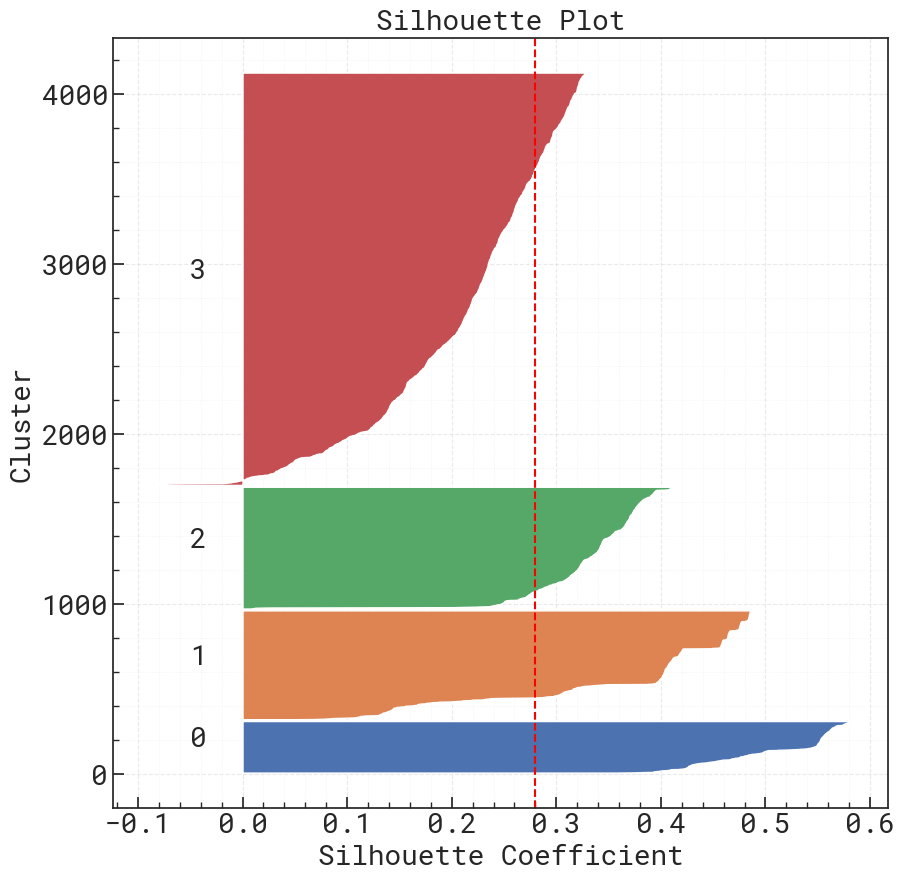

In [35]:
fig, ax = plt.subplots(figsize=(10,10))

y_lower = 10
for i in range(optimal_k):
    cluster_silhouette_vals = sample_silhouette_values[labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

# Average silhouette line
ax.axvline(x=avg_score, color="red", linestyle="--")

ax.set_title("Silhouette Plot")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")

# Apply your custom styling
styling.style_ax(ax)
# Note: style_legend usually requires labels; if silhouette has none, 
# this may need to be commented out or adjusted.
# styling.style_legend(ax) 

styling.save_figure(fig, x_label="Silhouette Coefficient", y_label="Cluster", save_path="../report/exports/")

plt.show()


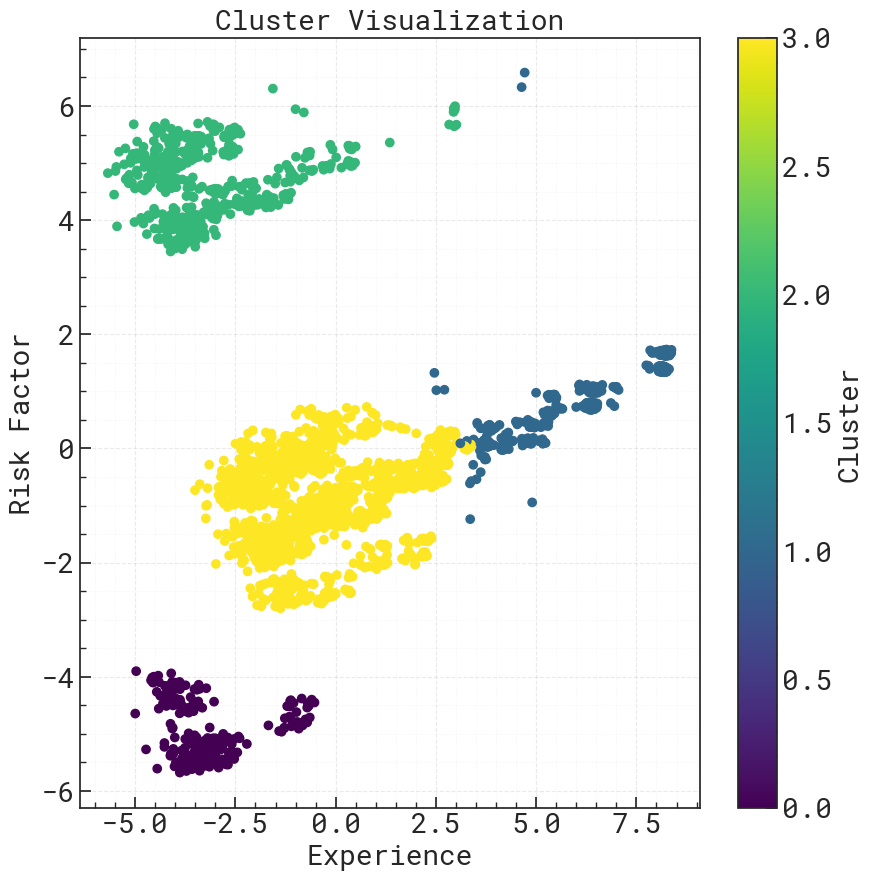

In [36]:
fig, ax = plt.subplots(figsize=(10,10))

scatter = ax.scatter(
    X_famd[0], 
    X_famd[1], 
    c=df_analysis['cluster'],
    cmap='viridis' # Good for visibility
)

ax.set_xlabel("Experience")
ax.set_ylabel("Risk Factor")
ax.set_title("Cluster Visualization")

# Add colorbar using the scatter object
plt.colorbar(scatter, ax=ax, label="Cluster")

# Apply custom styling
styling.style_ax(ax)
# If your styling.style_legend handles scatter handles, keep it here:
# styling.style_legend(ax) 

styling.save_figure(fig, x_label="Experience", y_label="Risk Factor", save_path="../report/exports/")

plt.show()

In [40]:
df['cluster'] = labels
df.to_csv("../data/train_with_clusters.csv")

In [41]:
test = pd.read_csv("../data/test.csv")

famd_fit = famd.fit(test[numeric_cols + categorical_cols])

X_famd = famd.transform(test[numeric_cols + categorical_cols])

labels = kmeans.fit_predict(X_famd)

ValueError: Shape of passed values is (1022, 10), indices imply (4088, 10)